# Etapa 1 — EDA: Bank Marketing (bank-additional-full)

Base: [Bank Marketing Data Set (Yamahata) — Kaggle](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing)

Objetivo desta EDA:
1. Entender as colunas disponíveis e a variável alvo (`y`).
2. Identificar problemas de qualidade dos dados (valores `unknown`, vazamento temporal).
3. Levantar candidatos a **contexto** (features do cliente) e a **braços** (ações/ofertas) para o desenho do bandit nas Etapas 2-3.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = Path("../data/raw/bank-additional-full.csv")

In [3]:
df = pd.read_csv(DATA_PATH, sep=";")
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1. Visão geral

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [5]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [6]:
df.describe(include="object").T

C:\Users\lfell\AppData\Local\Temp\ipykernel_17068\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


## 2. Variável alvo (`y`)

`y` indica se o cliente assinou o depósito a prazo. É a nossa proxy de **conversão/reward** para o bandit.

y
no     0.887346
yes    0.112654
Name: proporcao, dtype: float64


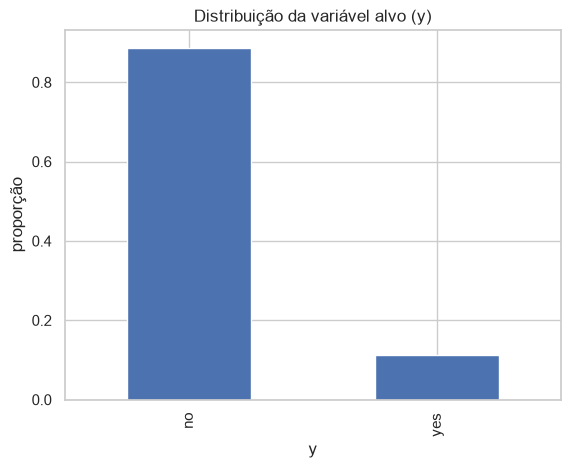

In [7]:
target_dist = df["y"].value_counts(normalize=True).rename("proporcao")
print(target_dist)
target_dist.plot(kind="bar", title="Distribuição da variável alvo (y)")
plt.ylabel("proporção")
plt.show()

Dataset desbalanceado (conversão minoritária) — comum em campanhas de marketing. Isso é relevante tanto para o baseline quanto para a leitura das taxas de conversão por braço nas próximas etapas: com poucas conversões totais, comparações por segmento pequeno tendem a ser ruidosas.

## 3. Valores `unknown` (dados faltantes disfarçados)

O dataset não usa `NaN` — valores ausentes em colunas categóricas vêm como a string `"unknown"`.

In [8]:
categorical_cols = df.select_dtypes(include="object").columns.drop("y")

unknown_counts = pd.DataFrame({
    col: [(df[col] == "unknown").sum(), round((df[col] == "unknown").mean() * 100, 2)]
    for col in categorical_cols
}, index=["contagem", "pct"]).T.sort_values("pct", ascending=False)

unknown_counts[unknown_counts["contagem"] > 0]

C:\Users\lfell\AppData\Local\Temp\ipykernel_17068\1856490510.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.drop("y")


,contagem,pct
default,8597.0,20.87
education,1731.0,4.20
housing,990.0,2.40
loan,990.0,2.40
job,330.0,0.80
marital,80.0,0.19


**Decisão para a Etapa 2**: manter `"unknown"` como categoria própria (não descartar linhas) — colunas como `default` têm alta proporção de unknown, e remover essas linhas jogaria fora muitos clientes.

## 4. ⚠️ Vazamento temporal: coluna `duration`

`duration` (duração da ligação) só é conhecida **depois** que a ligação acontece — ou seja, depois que a decisão de oferta já foi tomada e o resultado já é sabido. Usar essa coluna para prever `y` é vazamento de dados (data leakage): o próprio enunciado do desafio pede para descartá-la.

Vamos confirmar a relação forte entre `duration` e `y` antes de descartar.

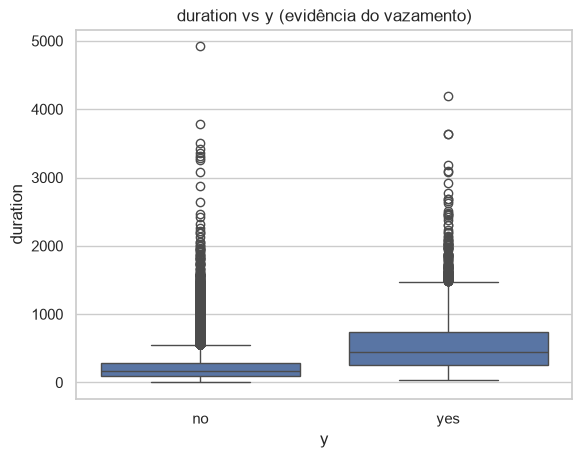

In [9]:
sns.boxplot(data=df, x="y", y="duration")
plt.title("duration vs y (evidência do vazamento)")
plt.show()

In [10]:
df = df.drop(columns=["duration"])
print("Coluna 'duration' removida. Shape atual:", df.shape)

Coluna 'duration' removida. Shape atual: (41188, 20)


## 5. Distribuições numéricas

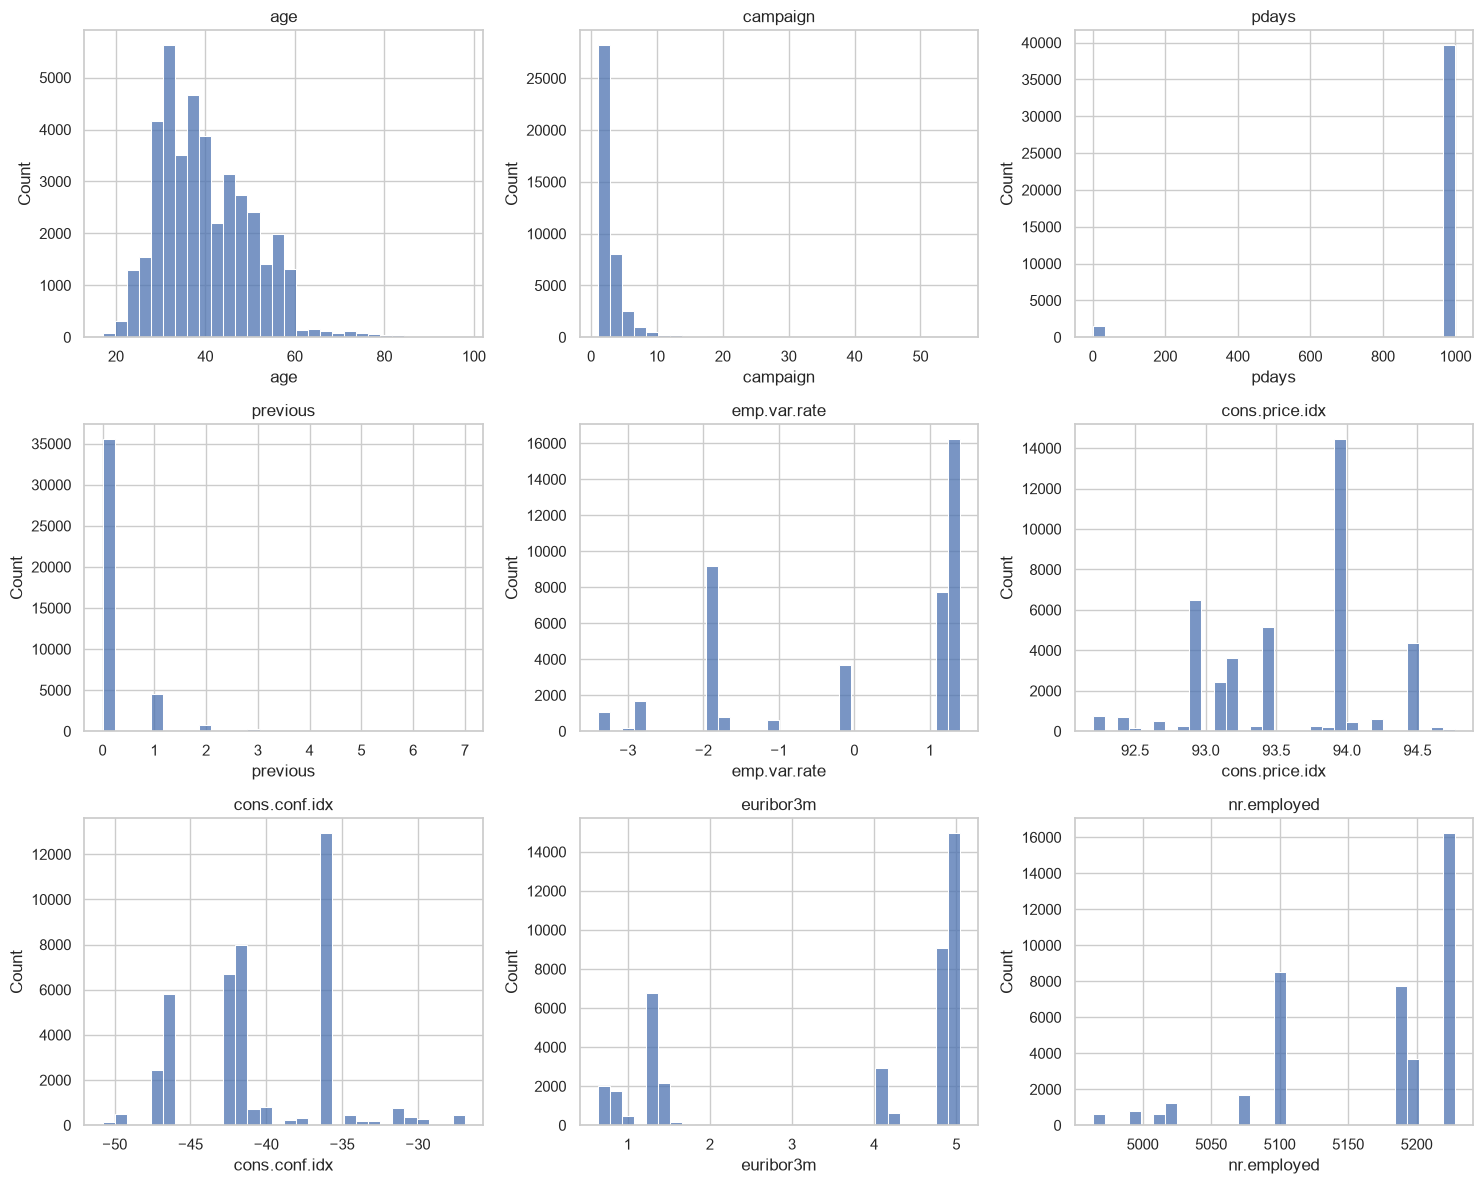

In [11]:
numeric_cols = df.select_dtypes(include="number").columns

fig, axes = plt.subplots(nrows=(len(numeric_cols) + 2) // 3, ncols=3, figsize=(15, 4 * ((len(numeric_cols) + 2) // 3)))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], ax=ax, bins=30)
    ax.set_title(col)
for ax in axes.flat[len(numeric_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Atenção a `pdays`: o valor `999` é um código especial para "cliente nunca contatado antes", não uma medida contínua real — deve ser tratado como categoria/flag na Etapa 2, não como número puro.

In [12]:
(df["pdays"] == 999).mean()

np.float64(0.9632174419733903)

## 6. Correlação entre variáveis numéricas

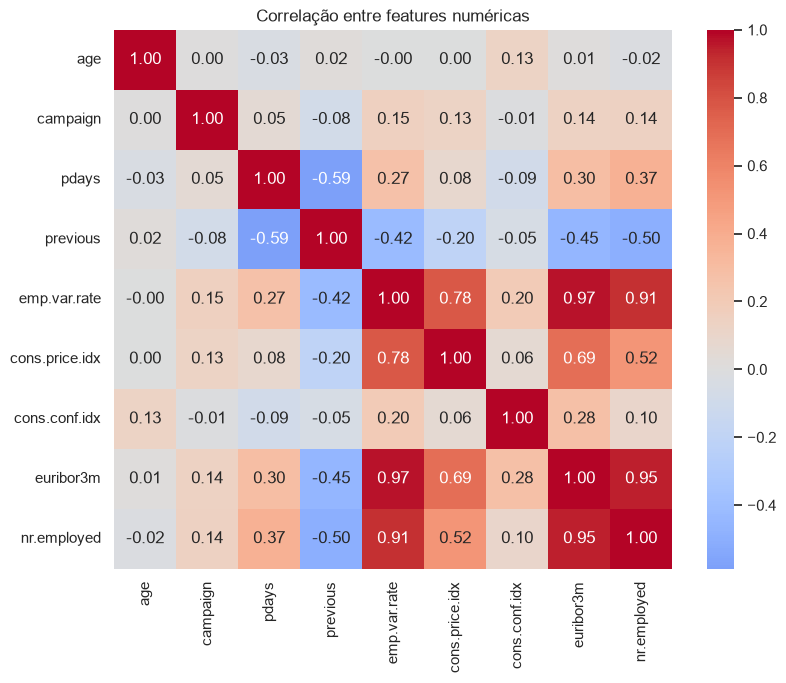

In [13]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre features numéricas")
plt.show()

As cinco variáveis socioeconômicas (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) são fortemente correlacionadas entre si — fazem sentido como indicadores macro do mesmo período, e não representam informação por cliente.

## 7. Taxa de conversão por variável categórica

Aqui olhamos quais colunas categóricas parecem discriminar melhor a conversão — candidatas a **contexto** (features do cliente) e/ou a **braços** (ação testada) no desenho do bandit.

In [14]:
df["y_bin"] = (df["y"] == "yes").astype(int)

for col in ["job", "marital", "education", "contact", "month", "poutcome", "housing", "loan", "default"]:
    rate = df.groupby(col)["y_bin"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    print(f"\n--- {col} ---")
    print(rate)


--- job ---
                   mean  count
job                           
student        0.314286    875
retired        0.252326   1720
unemployed     0.142012   1014
admin.         0.129726  10422
management     0.112175   2924
unknown        0.112121    330
technician     0.108260   6743
self-employed  0.104856   1421
housemaid      0.100000   1060
entrepreneur   0.085165   1456
services       0.081381   3969
blue-collar    0.068943   9254

--- marital ---
              mean  count
marital                  
unknown   0.150000     80
single    0.140041  11568
divorced  0.103209   4612
married   0.101573  24928

--- education ---
                         mean  count
education                           
illiterate           0.222222     18
unknown              0.145003   1731
university.degree    0.137245  12168
professional.course  0.113485   5243
high.school          0.108355   9515
basic.4y             0.102490   4176
basic.6y             0.082024   2292
basic.9y             0.07824

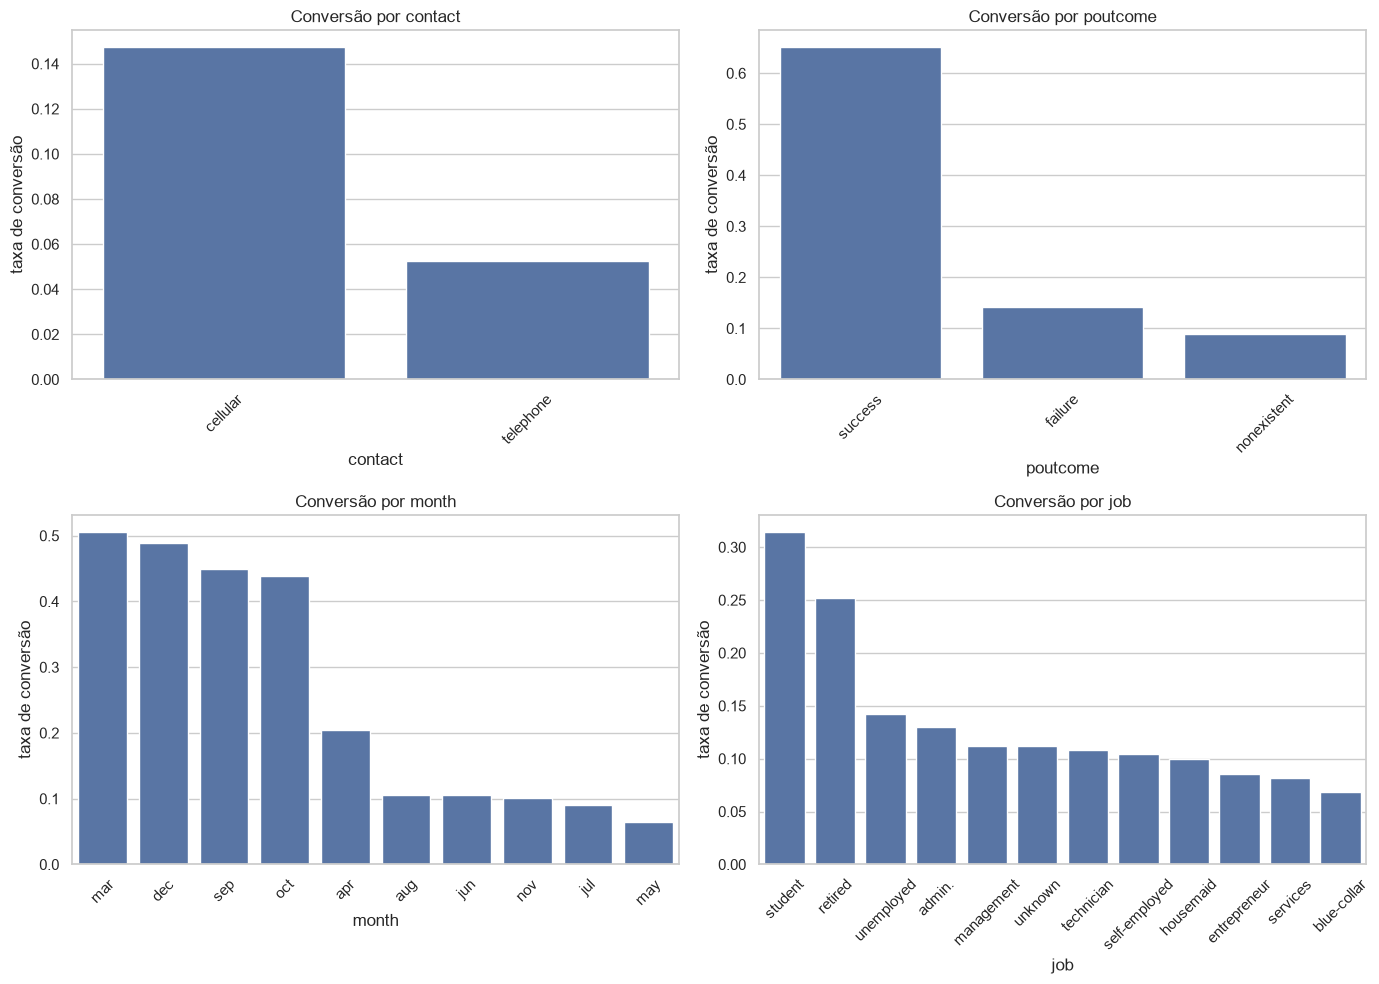

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, ["contact", "poutcome", "month", "job"]):
    order = df.groupby(col)["y_bin"].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y="y_bin", order=order, ax=ax, errorbar=None)
    ax.set_ylabel("taxa de conversão")
    ax.set_title(f"Conversão por {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observações relevantes para o desenho do bandit (Etapas 2-3):**

- `poutcome` (resultado da campanha anterior) mostra forte diferença de conversão entre `success`, `failure` e `nonexistent` — sinal de que o histórico do cliente importa como *contexto*.
- `contact` (celular vs. telefone fixo) e `month` também discriminam bastante a conversão — são candidatos naturais a **braços** ("canal de contato" ou "época de abordagem" como ação testável), já que representam decisões que a instituição controla, ao contrário de atributos fixos do cliente como `job` ou `education`.
- `job`/`education`/`marital` são atributos do cliente (não uma decisão da instituição) — funcionam melhor como **contexto** de entrada do que como braço.

## 8. Conclusões e próximos passos (Etapa 2)

- **Target/reward**: `y` (`yes`/`no`) → `y_bin` (1/0).
- **Remover**: `duration` (vazamento temporal, confirmado acima).
- **Tratar como categoria**: valores `unknown` mantidos como classe própria; `pdays == 999` deve virar uma flag binária (`nunca_contatado`) em vez de número contínuo.
- **Contexto (features do cliente)**: `age`, `job`, `marital`, `education`, `default`, `housing`, `loan`, `campaign`, `previous`, `poutcome`, + indicadores macro.
- **Candidatos a braço (ação testável)**: `contact` (canal) e/ou `month` (época) — a definir com mais detalhe na Etapa 2, já que a base não vem com múltiplas ofertas pré-rotuladas.
- Dataset desbalanceado → considerar isso ao interpretar taxas de conversão por segmento pequeno.